<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/05_batch_normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 05 — Batch Normalization, Layer Normalization & Group Normalization

## What This Notebook Covers
Normalization layers are one of the most impactful innovations in deep learning.
They solve the problem of **internal covariate shift** — the phenomenon where the
distribution of each layer's inputs keeps changing during training as the weights
of the previous layers change. This forces every layer to constantly re-adapt,
slowing training dramatically.

Normalization layers re-center and re-scale activations so that the distribution
stays stable throughout training.

**Techniques covered:**
- Batch Normalization (BatchNorm) — normalizes across the batch dimension
- Layer Normalization (LayerNorm) — normalizes across the feature dimension
- Group Normalization (GroupNorm) — normalizes within groups of channels
- Pre-activation vs post-activation BatchNorm placement
- A/B tests: with vs without normalization

**Both TensorFlow and PyTorch implementations are shown.**

**Dataset:** Fashion-MNIST


In [1]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data


In [2]:
# TensorFlow data
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]
print('TF data ready.')

# PyTorch data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full_pt = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set_pt   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_set_pt, valid_set_pt = torch.utils.data.random_split(
    train_full_pt, [55000, 5000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set_pt, batch_size=64, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_set_pt, batch_size=64, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_set_pt,  batch_size=64, shuffle=False, pin_memory=True)
print('PyTorch data ready.')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
TF data ready.


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 319kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.13MB/s]

PyTorch data ready.


## 2. The Problem: Activation Distribution Drift

Without normalization, the distribution of activations shifts as weights update.
We visualize this by tracking the mean and std of activations at each layer
during a forward pass, before any training.


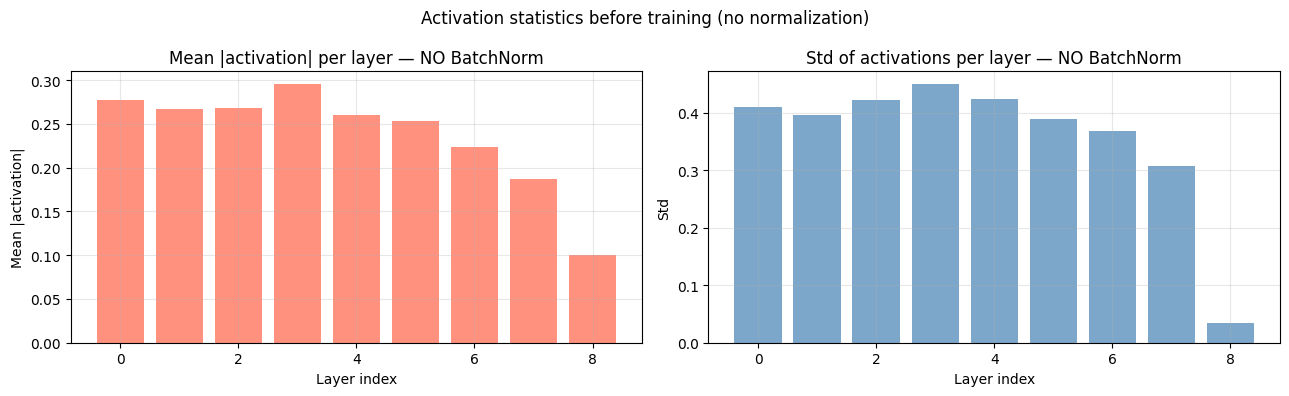

Notice how activation scale changes across layers — this is the drift BatchNorm fixes.


In [5]:
def get_layer_activation_stats(model, X_sample):
    """
    Run a forward pass and collect mean + std of activations at each Dense layer.
    Uses a Keras functional hook via intermediate model outputs.
    """
    # Ensure the model is built by calling it once with sample data
    # This is crucial for accessing model.input with Sequential models
    # if the model wasn't built using tf.keras.Input directly.
    _ = model(X_sample[:1], training=False)

    # Build an intermediate model that outputs every layer's activation
    layer_outputs = [layer.output for layer in model.layers
                     if isinstance(layer, tf.keras.layers.Dense)]
    if not layer_outputs:
        return [], []
    intermediate = tf.keras.Model(inputs=model.input, outputs=layer_outputs)
    activations  = intermediate(X_sample, training=False)
    if not isinstance(activations, list):
        activations = [activations]
    means = [float(tf.reduce_mean(tf.abs(a)).numpy()) for a in activations]
    stds  = [float(tf.math.reduce_std(a).numpy())     for a in activations]
    return means, stds


# Build a deep model WITHOUT batch norm and check activation stats
def make_plain_deep(n_layers=8, units=200):
    # Use tf.keras.Input to explicitly define the input tensor for the model.
    # This makes model.input a proper KerasTensor from the start,
    # resolving issues when used in tf.keras.Model(inputs=...).
    inputs = tf.keras.Input(shape=(28, 28))
    x = tf.keras.layers.Flatten()(inputs)
    for _ in range(n_layers):
        x = tf.keras.layers.Dense(units, activation='relu',
                                 kernel_initializer='he_normal')(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


plain_model = make_plain_deep(n_layers=8)
X_sample_tf = X_train[:256]

means_plain, stds_plain = get_layer_activation_stats(plain_model, X_sample_tf)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(len(means_plain)), means_plain, color='tomato', alpha=0.7)
axes[0].set_title('Mean |activation| per layer — NO BatchNorm')
axes[0].set_xlabel('Layer index')
axes[0].set_ylabel('Mean |activation|')
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(stds_plain)), stds_plain, color='steelblue', alpha=0.7)
axes[1].set_title('Std of activations per layer — NO BatchNorm')
axes[1].set_xlabel('Layer index')
axes[1].set_ylabel('Std')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Activation statistics before training (no normalization)', fontsize=12)
plt.tight_layout()
plt.show()

print('Notice how activation scale changes across layers — this is the drift BatchNorm fixes.')

## 3. Batch Normalization — Concept

BatchNorm normalizes the activations of a layer **across the batch dimension**
for each feature independently.

For a mini-batch of activations with shape `(batch_size, n_features)`:

```
mu    = mean across batch dimension   -> shape (n_features,)
sigma = std  across batch dimension   -> shape (n_features,)
x_hat = (x - mu) / (sigma + epsilon)  -> normalized, zero mean, unit variance
y     = gamma * x_hat + beta           -> scale and shift (learned parameters)
```

gamma and beta are **learned** — the network can undo the normalization if needed.
epsilon (typically 1e-5) prevents division by zero.

At inference time, BatchNorm uses **running mean and variance** accumulated
during training instead of batch statistics.
This is why `model.train()` vs `model.eval()` matters in PyTorch.


## 4. A/B Test: With vs Without Batch Normalization (TensorFlow)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


No BatchNorm                        -> best val accuracy: 0.8938
With BatchNorm                      -> best val accuracy: 0.8742


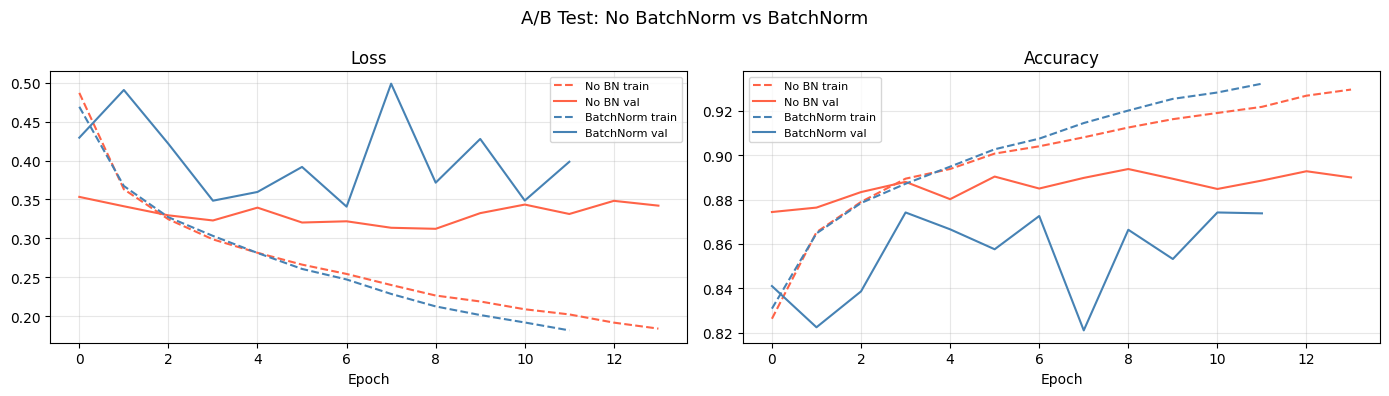

In [6]:
def make_model_no_bn():
    """Deep model with no normalization — our baseline."""
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])


def make_model_with_bn():
    """
    Post-activation BatchNorm placement (most common):
    Dense -> Activation -> BatchNorm
    BatchNorm normalizes the output of the activation before it goes
    into the next layer.
    """
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])


def compile_and_train(model, epochs=20, label=''):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )
    best_val = max(history.history['val_accuracy'])
    print(f'{label:35s} -> best val accuracy: {best_val:.4f}')
    return history


tf.random.set_seed(42)
model_no_bn = make_model_no_bn()
hist_no_bn  = compile_and_train(model_no_bn, epochs=25, label='No BatchNorm')

tf.random.set_seed(42)
model_bn   = make_model_with_bn()
hist_bn    = compile_and_train(model_bn, epochs=25, label='With BatchNorm')

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(hist_no_bn.history[metric],           '--', color='tomato',    label='No BN train')
    ax.plot(hist_no_bn.history[f'val_{metric}'],        color='tomato',    label='No BN val')
    ax.plot(hist_bn.history[metric],              '--', color='steelblue', label='BatchNorm train')
    ax.plot(hist_bn.history[f'val_{metric}'],           color='steelblue', label='BatchNorm val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('A/B Test: No BatchNorm vs BatchNorm', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Pre-Activation vs Post-Activation BatchNorm Placement

There are two common placements for BatchNorm:

**Post-activation (original paper):**
```
Dense -> ReLU -> BatchNorm
```

**Pre-activation (often better for deep nets):**
```
Dense -> BatchNorm -> ReLU
```
The pre-activation style normalizes inputs BEFORE the activation fires,
which keeps the inputs to ReLU centered around zero so both positive
and negative values can influence the gradient.


Pre-activation BN                   -> best val accuracy: 0.8714


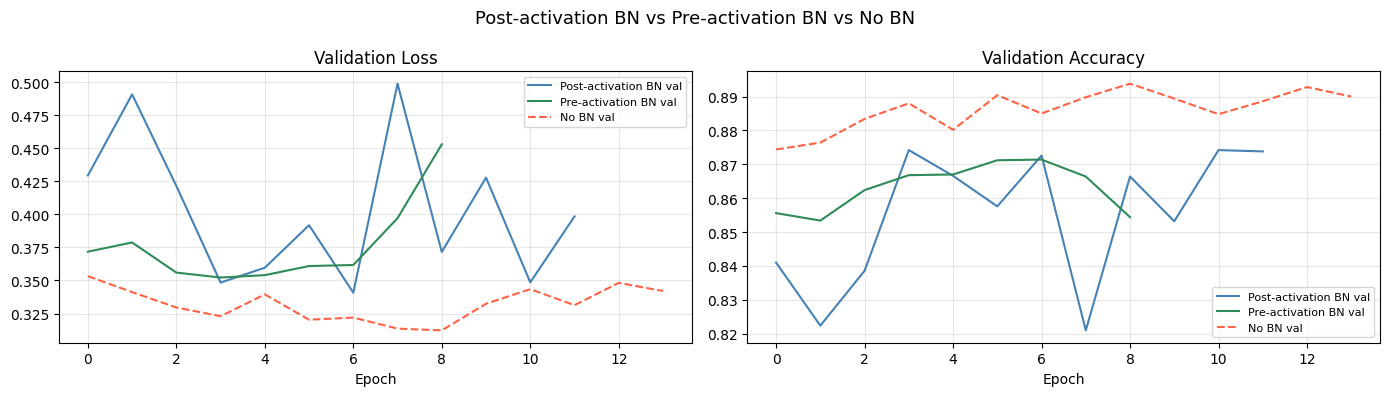

In [7]:
def make_pre_activation_bn():
    """
    Pre-activation BatchNorm: Dense -> BatchNorm -> ReLU
    Note: no activation argument in Dense — we add it manually after BN.
    """
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        # Block 1
        tf.keras.layers.Dense(300, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        # Block 2
        tf.keras.layers.Dense(200, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        # Block 3
        tf.keras.layers.Dense(100, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


tf.random.set_seed(42)
model_pre_bn = make_pre_activation_bn()
hist_pre_bn  = compile_and_train(model_pre_bn, epochs=25, label='Pre-activation BN')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(hist_bn.history[f'val_{metric}'],     color='steelblue', label='Post-activation BN val')
    ax.plot(hist_pre_bn.history[f'val_{metric}'], color='seagreen',  label='Pre-activation BN val')
    ax.plot(hist_no_bn.history[f'val_{metric}'],  color='tomato',    label='No BN val', linestyle='--')
    ax.set_title(f'Validation {title}')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('Post-activation BN vs Pre-activation BN vs No BN', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Layer Normalization — Concept & Implementation

LayerNorm normalizes across the **feature dimension** for each sample independently.
Unlike BatchNorm, it does NOT depend on the batch — it works the same way
during training and inference, and it works with batch size = 1.

```
For one sample x of shape (n_features,):
mu    = mean(x)                         -> scalar
sigma = std(x)                          -> scalar
x_hat = (x - mu) / (sigma + epsilon)   -> normalized
y     = gamma * x_hat + beta            -> scaled and shifted (learned)
```

LayerNorm is the standard choice for:
- Transformers and attention mechanisms
- NLP models (BERT, GPT)
- Any setting where batch size varies or is small


LayerNorm                           -> best val accuracy: 0.8970


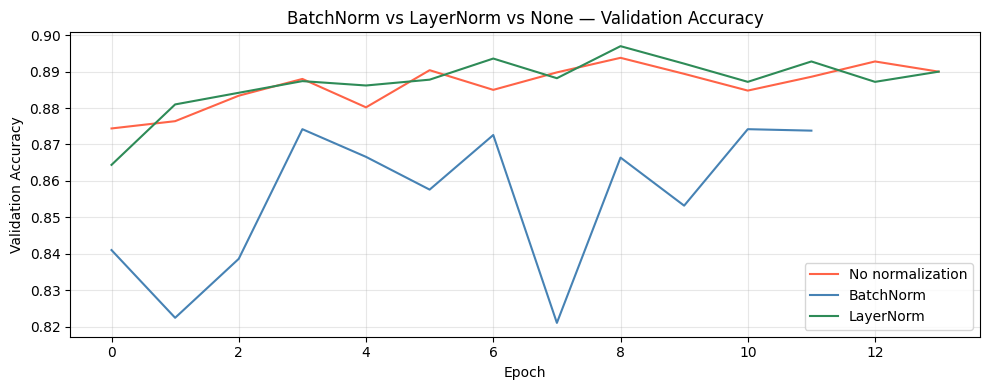

In [8]:
def make_model_layer_norm():
    """Dense network with LayerNormalization instead of BatchNormalization."""
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.LayerNormalization(),     # normalizes each sample across all 300 features
        tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.LayerNormalization(),
        tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.LayerNormalization(),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


tf.random.set_seed(42)
model_ln = make_model_layer_norm()
hist_ln  = compile_and_train(model_ln, epochs=25, label='LayerNorm')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_no_bn.history['val_accuracy'], color='tomato',    label='No normalization')
ax.plot(hist_bn.history['val_accuracy'],    color='steelblue', label='BatchNorm')
ax.plot(hist_ln.history['val_accuracy'],    color='seagreen',  label='LayerNorm')
ax.set_title('BatchNorm vs LayerNorm vs None — Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Visualising What Each Norm Does to a Feature Map

We manually demonstrate the normalization math to make it concrete.


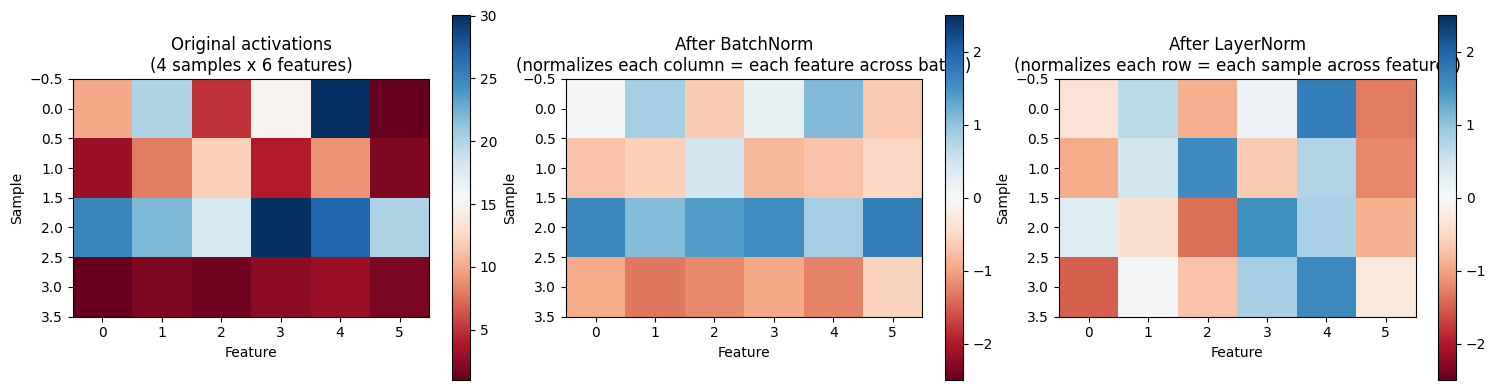

BatchNorm: each column (feature) has mean~0, std~1 across the batch
LayerNorm: each row (sample) has mean~0, std~1 across its features


In [9]:
np.random.seed(0)
# Simulate a batch of 4 samples, each with 6 features
batch = np.array([
    [10.0, 20.0,  5.0, 15.0, 30.0,  1.0],
    [ 3.0,  8.0, 12.0,  4.0,  9.0,  2.0],
    [25.0, 22.0, 18.0, 30.0, 27.0, 20.0],
    [ 1.0,  2.0,  1.5,  2.5,  3.0,  1.8],
], dtype=np.float32)

eps = 1e-5

# BatchNorm: normalize across the BATCH dimension per feature
bn_mean = batch.mean(axis=0, keepdims=True)   # shape (1, 6)
bn_std  = batch.std(axis=0,  keepdims=True)   # shape (1, 6)
batch_normed = (batch - bn_mean) / (bn_std + eps)

# LayerNorm: normalize across the FEATURE dimension per sample
ln_mean = batch.mean(axis=1, keepdims=True)   # shape (4, 1)
ln_std  = batch.std(axis=1,  keepdims=True)   # shape (4, 1)
layer_normed = (batch - ln_mean) / (ln_std + eps)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmin, vmax = -2.5, 2.5

im0 = axes[0].imshow(batch,        cmap='RdBu', vmin=batch.min(), vmax=batch.max())
axes[0].set_title('Original activations\n(4 samples x 6 features)')
axes[0].set_xlabel('Feature'); axes[0].set_ylabel('Sample')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(batch_normed, cmap='RdBu', vmin=vmin, vmax=vmax)
axes[1].set_title('After BatchNorm\n(normalizes each column = each feature across batch)')
axes[1].set_xlabel('Feature'); axes[1].set_ylabel('Sample')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(layer_normed, cmap='RdBu', vmin=vmin, vmax=vmax)
axes[2].set_title('After LayerNorm\n(normalizes each row = each sample across features)')
axes[2].set_xlabel('Feature'); axes[2].set_ylabel('Sample')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

print('BatchNorm: each column (feature) has mean~0, std~1 across the batch')
print('LayerNorm: each row (sample) has mean~0, std~1 across its features')

## 8. BatchNorm: Training vs Inference Behaviour

This is one of the most common sources of bugs with BatchNorm.

**During training:**
- Uses statistics from the current mini-batch
- Also updates running_mean and running_var (exponential moving average)

**During inference:**
- Uses the accumulated running_mean and running_var from training
- Does NOT use batch statistics — results are deterministic

In Keras this is handled automatically by the `training` argument.
In PyTorch you MUST call `model.train()` / `model.eval()` correctly.


In [10]:
# Demonstrate BatchNorm running stats accumulation in TF
bn_layer = tf.keras.layers.BatchNormalization()

# Simulate training: pass batches with training=True
for _ in range(10):
    x_batch = tf.random.normal([64, 100], mean=5.0, stddev=2.0)
    _ = bn_layer(x_batch, training=True)   # updates running stats

# The moving average and variance are now stored in the layer
moving_mean = bn_layer.moving_mean.numpy()
moving_var  = bn_layer.moving_variance.numpy()

print('After 10 training batches (data had mean=5.0, std=2.0):')
print(f'  Running mean (first 5 features): {moving_mean[:5].round(3)}')
print(f'  Running var  (first 5 features): {moving_var[:5].round(3)}')
print()
print('At inference time (training=False), these stored values are used')
print('instead of computing batch statistics — making inference deterministic.')

# Show that inference output is deterministic
x_test_sample = tf.random.normal([4, 100], mean=5.0, stddev=2.0)
out1 = bn_layer(x_test_sample, training=False).numpy()
out2 = bn_layer(x_test_sample, training=False).numpy()
print(f'\nInference output identical across calls: {np.allclose(out1, out2)}')

After 10 training batches (data had mean=5.0, std=2.0):
  Running mean (first 5 features): [0.477 0.475 0.484 0.484 0.487]
  Running var  (first 5 features): [1.272 1.265 1.257 1.263 1.242]

At inference time (training=False), these stored values are used
instead of computing batch statistics — making inference deterministic.

Inference output identical across calls: True


## 9. Effect of Batch Size on BatchNorm

BatchNorm relies on having a reasonably sized batch to estimate statistics.
With very small batches the estimates are noisy and BatchNorm degrades.
LayerNorm does not have this problem.


Batch size    4 | BN val acc: 0.8176 | LN val acc: 0.8892
Batch size    8 | BN val acc: 0.8736 | LN val acc: 0.8862
Batch size   16 | BN val acc: 0.8874 | LN val acc: 0.8922
Batch size   32 | BN val acc: 0.8780 | LN val acc: 0.8894
Batch size   64 | BN val acc: 0.8718 | LN val acc: 0.8916
Batch size  128 | BN val acc: 0.8772 | LN val acc: 0.8884


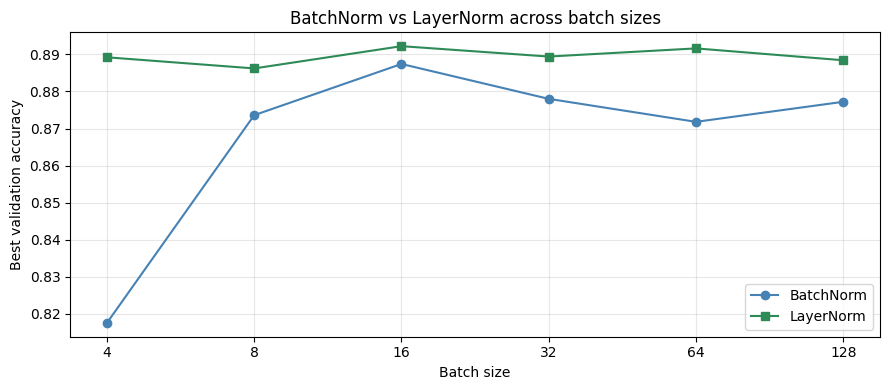

BatchNorm degrades at small batch sizes. LayerNorm is stable.


In [11]:
batch_sizes = [4, 8, 16, 32, 64, 128]
bn_accs, ln_accs = [], []

EPOCHS_BS = 10

for bs in batch_sizes:
    # BatchNorm
    tf.random.set_seed(42)
    m_bn = make_model_with_bn()
    m_bn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h_bn = m_bn.fit(X_train, y_train, validation_data=(X_valid, y_valid),
                    epochs=EPOCHS_BS, batch_size=bs, verbose=0)
    bn_accs.append(max(h_bn.history['val_accuracy']))

    # LayerNorm
    tf.random.set_seed(42)
    m_ln = make_model_layer_norm()
    m_ln.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h_ln = m_ln.fit(X_train, y_train, validation_data=(X_valid, y_valid),
                    epochs=EPOCHS_BS, batch_size=bs, verbose=0)
    ln_accs.append(max(h_ln.history['val_accuracy']))

    print(f'Batch size {bs:4d} | BN val acc: {bn_accs[-1]:.4f} | LN val acc: {ln_accs[-1]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(batch_sizes, bn_accs, marker='o', color='steelblue', label='BatchNorm')
plt.plot(batch_sizes, ln_accs, marker='s', color='seagreen',  label='LayerNorm')
plt.xscale('log', base=2)
plt.xlabel('Batch size')
plt.ylabel('Best validation accuracy')
plt.title('BatchNorm vs LayerNorm across batch sizes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(batch_sizes, batch_sizes)
plt.tight_layout()
plt.show()
print('BatchNorm degrades at small batch sizes. LayerNorm is stable.')

---
## Part B — PyTorch: BatchNorm, LayerNorm, GroupNorm

PyTorch provides `nn.BatchNorm1d`, `nn.LayerNorm`, and `nn.GroupNorm`.
The critical rule: always call `model.train()` during training and
`model.eval()` during validation so BatchNorm uses the right statistics.


In [12]:
class NetNoBN(nn.Module):
    """Baseline: no normalization."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.ReLU(),
            nn.Linear(300, 200), nn.ReLU(),
            nn.Linear(200, 100), nn.ReLU(),
            nn.Linear(100, 10)
        )
    def forward(self, x): return self.net(x)


class NetBatchNorm(nn.Module):
    """
    Post-activation BatchNorm.
    nn.BatchNorm1d expects input shape (batch, features).
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.ReLU(), nn.BatchNorm1d(300),
            nn.Linear(300, 200), nn.ReLU(), nn.BatchNorm1d(200),
            nn.Linear(200, 100), nn.ReLU(), nn.BatchNorm1d(100),
            nn.Linear(100, 10)
        )
    def forward(self, x): return self.net(x)


class NetLayerNorm(nn.Module):
    """
    LayerNorm after each activation.
    nn.LayerNorm takes the normalized_shape = number of features.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.ReLU(), nn.LayerNorm(300),
            nn.Linear(300, 200), nn.ReLU(), nn.LayerNorm(200),
            nn.Linear(200, 100), nn.ReLU(), nn.LayerNorm(100),
            nn.Linear(100, 10)
        )
    def forward(self, x): return self.net(x)


class NetGroupNorm(nn.Module):
    """
    GroupNorm divides features into G groups and normalizes within each group.
    nn.GroupNorm(num_groups, num_channels).
    num_channels must be divisible by num_groups.
    GroupNorm is batch-size independent like LayerNorm.
    """
    def __init__(self, num_groups=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.ReLU(), nn.GroupNorm(num_groups, 300),
            nn.Linear(300, 200), nn.ReLU(), nn.GroupNorm(num_groups, 200),
            nn.Linear(200, 100), nn.ReLU(), nn.GroupNorm(num_groups, 100),
            nn.Linear(100, 10)
        )
    def forward(self, x): return self.net(x)


print('PyTorch model classes defined.')

PyTorch model classes defined.


In [13]:
def train_eval_pt(model, epochs=15, label='', lr=1e-3):
    model    = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    hist      = {'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()   # CRITICAL for BatchNorm — uses batch statistics
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()

        model.eval()    # CRITICAL for BatchNorm — uses running statistics
        def get_acc(loader):
            correct = total = 0
            with torch.no_grad():
                for X_b, y_b in loader:
                    X_b, y_b = X_b.to(device), y_b.to(device)
                    correct += (model(X_b).argmax(1) == y_b).sum().item()
                    total   += y_b.size(0)
            return correct / total

        t_acc = get_acc(train_loader)
        v_acc = get_acc(valid_loader)
        hist['train_acc'].append(t_acc)
        hist['val_acc'].append(v_acc)

        if (epoch + 1) % 5 == 0:
            print(f'  {label} Epoch {epoch+1:2d} | train={t_acc:.4f} | val={v_acc:.4f}')

    best = max(hist['val_acc'])
    print(f'  {label} best val acc: {best:.4f}\n')
    return hist


models_pt = [
    ('No Normalization', NetNoBN()),
    ('BatchNorm1d',      NetBatchNorm()),
    ('LayerNorm',        NetLayerNorm()),
    ('GroupNorm(G=10)',  NetGroupNorm(num_groups=10)),
]

histories_pt = {}
for label, model in models_pt:
    torch.manual_seed(42)
    print(f'Training: {label}')
    histories_pt[label] = train_eval_pt(model, epochs=15, label=label)

Training: No Normalization
  No Normalization Epoch  5 | train=0.9026 | val=0.8812
  No Normalization Epoch 10 | train=0.9211 | val=0.8806
  No Normalization Epoch 15 | train=0.9229 | val=0.8736
  No Normalization best val acc: 0.8892

Training: BatchNorm1d
  BatchNorm1d Epoch  5 | train=0.9018 | val=0.8714
  BatchNorm1d Epoch 10 | train=0.9231 | val=0.8832
  BatchNorm1d Epoch 15 | train=0.9400 | val=0.8862
  BatchNorm1d best val acc: 0.8862

Training: LayerNorm
  LayerNorm Epoch  5 | train=0.9057 | val=0.8832
  LayerNorm Epoch 10 | train=0.9213 | val=0.8848
  LayerNorm Epoch 15 | train=0.9235 | val=0.8776
  LayerNorm best val acc: 0.8866

Training: GroupNorm(G=10)
  GroupNorm(G=10) Epoch  5 | train=0.8949 | val=0.8732
  GroupNorm(G=10) Epoch 10 | train=0.9184 | val=0.8794
  GroupNorm(G=10) Epoch 15 | train=0.9199 | val=0.8702
  GroupNorm(G=10) best val acc: 0.8844



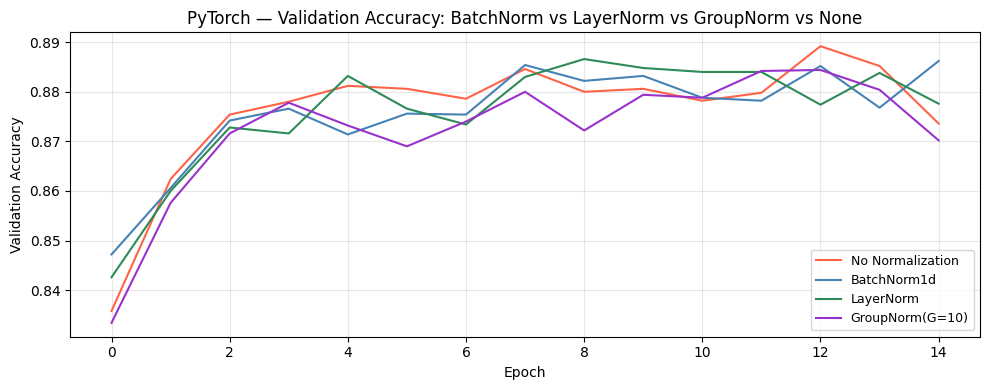

In [14]:
colors = ['tomato', 'steelblue', 'seagreen', 'darkorchid']
plt.figure(figsize=(10, 4))
for (label, _), color in zip(models_pt, colors):
    plt.plot(histories_pt[label]['val_acc'], label=label, color=color)
plt.title('PyTorch — Validation Accuracy: BatchNorm vs LayerNorm vs GroupNorm vs None')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

| Norm Type | Normalizes over | Best for | Batch-size sensitive? |
|---|---|---|---|
| BatchNorm | Batch dimension, per feature | CNNs, dense nets, large batches | YES — degrades with small batches |
| LayerNorm | Feature dimension, per sample | Transformers, NLP, variable batch | No |
| GroupNorm | Groups of features, per sample | CNNs with small batches, detection | No |

**Placement rule of thumb:**
- Post-activation (Dense -> ReLU -> BN): original paper, most common
- Pre-activation  (Dense -> BN -> ReLU): often better for very deep nets

**Most important PyTorch rule:**
Always call `model.train()` before the training loop and `model.eval()`
before validation. Forgetting this with BatchNorm gives wrong results.

**Next: Notebook 06** — Custom Dropout and Custom Regularizer from scratch
